In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# Caso paralelo - ajuste sin curvefit + +simple

In [ ]:
#intento + simplificado 
def model(theta, S0, S1, S2, S3, d1, d2, d3, d4):

    theta_mod = theta % (2*np.pi)

#la funcion piecewise lo que hace es simplemente usar un delta segu el rango del theta
    delta = np.piecewise(
        theta_mod,
        [
            (theta_mod < np.pi/2),
            (theta_mod >= np.pi/2) & (theta_mod < np.pi),
            (theta_mod >= np.pi) & (theta_mod < 3*np.pi/2),
            (theta_mod >= 3*np.pi/2)
        ],
        [d1, d2, d3, d4]
    )

    a0  = S0/2 + S1/4*(1 + np.cos(delta))
    a4c = S1/4*(1 - np.cos(delta))
    a4s = S2/4*(1 - np.cos(delta))
    a2  = -S3/2*np.sin(delta)

    return (
        a0
        + a2*np.sin(2*theta)
        + a4c*np.cos(4*theta)
        + a4s*np.sin(4*theta)
    )


In [ ]:
def fit_una_vuelta(theta, I, plot=True):

    # ordenar por theta (por las dudas)
    idx = np.argsort(theta)
    theta = theta[idx]
    I = I[idx]

    # llevar theta a [0, 2pi]
    theta = theta - theta.min()

    # normalización robusta
    I = I / np.max(I)
    S0 = np.max(I)

    # errores
    theta_err = np.deg2rad(2)
    V_div = 0.005
    V_full_scale = 8 * V_div
    res_err = V_full_scale / 256

    I_err = np.sqrt((0.03 * I)**2 + res_err**2)

    # residuals
    def residuals(params):
        S1, S2, S3, d1, d2, d3, d4 = params
        return (model(theta, S0, S1, S2, S3, d1, d2, d3, d4) - I) / I_err

    # initial guess
    initial_guess = [
        0.1*S0, 0.1*S0, 0.1*S0,
        np.pi/2, np.pi/2, np.pi/2, np.pi/2
    ]

    bounds = (
        [-S0, -S0, -S0, 0, 0, 0, 0],
        [ S0,  S0,  S0, 2*np.pi, 2*np.pi, 2*np.pi, 2*np.pi]
    )

    result = least_squares(residuals, initial_guess, bounds=bounds)

    S1, S2, S3, d1, d2, d3, d4 = result.x

    # covarianza
    J = result.jac
    cov = np.linalg.pinv(J.T @ J) * np.sum(result.fun**2) / (len(I) - len(result.x))
    errors = np.sqrt(np.diag(cov))

    S1_err, S2_err, S3_err = errors[:3]

    # DOP
    DOP = np.sqrt(S1**2 + S2**2 + S3**2) / S0

    # resultados
    resultados = {
        "S0": S0,
        "S1": S1, "S2": S2, "S3": S3,
        "S1_err": S1_err, "S2_err": S2_err, "S3_err": S3_err,
        "DOP": DOP
    }

    # =========================
    # PLOTS
    # =========================
    if plot:
        theta_fit = np.linspace(0, 2*np.pi, 500)
        I_fit = model(theta_fit, S0, S1, S2, S3, d1, d2, d3, d4)

        plt.errorbar(theta, I, yerr=I_err, fmt='o', capsize=3, label="Datos")
        plt.plot(theta_fit, I_fit, label="Ajuste", color="orange")

        plt.xlabel("Theta (rad)")
        plt.ylabel("Intensidad")
        plt.legend()
        plt.grid()
        plt.show()

    return resultados


# para muchas vueltas
def fit_muchas_vueltas(theta_total, I_total):

    vuelta_idx = (theta_total // (2*np.pi)).astype(int) #esto hace que dentro de un archivo que tengo todas las vueltas, las separe cada 360 grados

    resultados = []

    for v in np.unique(vuelta_idx):

        mask = vuelta_idx == v

        theta = theta_total[mask]
        I = I_total[mask]

        res = fit_una_vuelta(theta, I, plot=False)

        resultados.append(res)

    return resultados





In [9]:
#para que quede mas lindo los rdos

def imprimir_resultados(res):

    S0 = res["S0"]

    S1 = res["S1"]
    S2 = res["S2"]
    S3 = res["S3"]

    S1_err = res["S1_err"]
    S2_err = res["S2_err"]
    S3_err = res["S3_err"]

    # =========================
    # vector de Poincaré
    # =========================
    s1 = S1 / S0
    s2 = S2 / S0
    s3 = S3 / S0

    s1_err = S1_err / S0
    s2_err = S2_err / S0
    s3_err = S3_err / S0

    # =========================
    # DOP
    # =========================
    DOP = np.sqrt(S1**2 + S2**2 + S3**2) / S0

    DOP_err = (
        1/S0
        * np.sqrt(
            (S1*S1_err)**2 +
            (S2*S2_err)**2 +
            (S3*S3_err)**2
        )
        / np.sqrt(S1**2 + S2**2 + S3**2)
    )

    # =========================
    # impresión
    # =========================
    print("\n==============================")
    print(" RESULTADOS DEL AJUSTE")
    print("==============================\n")

    print(f"S0 = {S0:.5f}")

    print("\n--- Vector de Stokes ---\n")

    print(f"S1 = {S1:.5f} ± {S1_err:.5f}")
    print(f"S2 = {S2:.5f} ± {S2_err:.5f}")
    print(f"S3 = {S3:.5f} ± {S3_err:.5f}")

    print("\n--- Vector de Poincaré ---\n")

    print(f"s1 = {s1:.5f} ± {s1_err:.5f}")
    print(f"s2 = {s2:.5f} ± {s2_err:.5f}")
    print(f"s3 = {s3:.5f} ± {s3_err:.5f}")

    print("\n--- Polarización ---\n")

    print(f"DOP = {DOP:.5f} ± {DOP_err:.5f}")

    print("\n==============================\n")

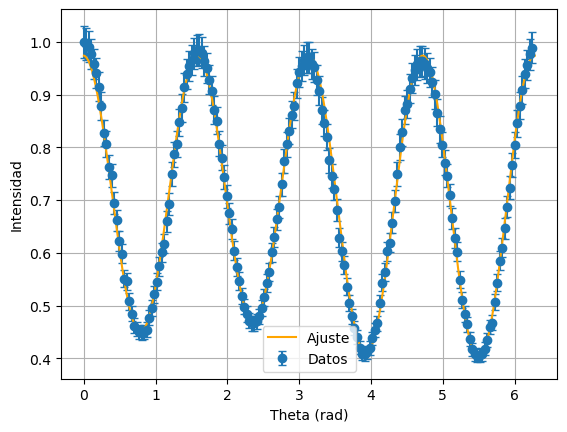


 RESULTADOS DEL AJUSTE

S0 = 1.00000

--- Vector de Stokes ---

S1 = 0.94722 ± 0.00404
S2 = 0.00476 ± 0.00442
S3 = 0.03627 ± 0.01480

--- Vector de Poincaré ---

s1 = 0.94722 ± 0.00404
s2 = 0.00476 ± 0.00442
s3 = 0.03627 ± 0.01480

--- Polarización ---

DOP = 0.94792 ± 0.00407


{'S0': 1.0, 'S1': 0.9472165975472362, 'S2': 0.00476255264132447, 'S3': 0.0362703719368958, 'S1_err': 0.004036940828444474, 'S2_err': 0.004424778536929608, 'S3_err': 0.014804252531957433, 'DOP': 0.9479227312693081}


In [10]:
#para una vuleta

medicion = pd.read_csv('Measurements/medicion_manual_polarimetro_paralelo2.csv')

theta = medicion['angulo'].values * np.pi/180
I = medicion['voltaje'].values - 0.00194

res = fit_una_vuelta(theta, I)
imprimir_resultados(res)

print(res)


In [ ]:
#para muchas vueltas

medicion = pd.read_csv('Measurements/archivo_con_muchas_vueltas.csv')

theta_total = medicion['angulo'].values * np.pi/180
I_total = medicion['voltaje'].values - 0.00194

resultados = fit_muchas_vueltas(theta_total, I_total)

# ejemplo: ver S1 de cada vuelta
S1_vals = [r["S1"] for r in resultados]

print("Promedio S1:", np.mean(S1_vals))
print("Std S1:", np.std(S1_vals))

## Poincare 

In [6]:
from mpl_toolkits.mplot3d import Axes3D

def plot_poincare_sphere(stokes_list):

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')

    # =========================
    # esfera
    # =========================
    u = np.linspace(0, 2*np.pi, 80)
    v = np.linspace(0, np.pi, 40)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(x, y, z, alpha=0.15)

    # =========================
    # ejes
    # =========================
    ax.plot([-1,1],[0,0],[0,0], lw=1)
    ax.plot([0,0],[-1,1],[0,0], lw=1)
    ax.plot([0,0],[0,0],[-1,1], lw=1)

    # =========================
    # puntos
    # =========================
    for i, res in enumerate(stokes_list):

        s1 = res["S1"] / res["S0"]
        s2 = res["S2"] / res["S0"]
        s3 = res["S3"] / res["S0"]

        ax.scatter(s1, s2, s3, s=80)

        ax.plot(
            [0, s1],
            [0, s2],
            [0, s3],
            '--',
            lw=1.5
        )

        ax.text(s1, s2, s3, f"{i}")

    # =========================
    # labels
    # =========================
    ax.set_xlabel("s1")
    ax.set_ylabel("s2")
    ax.set_zlabel("s3")

    ax.set_xlim(-1,1)
    ax.set_ylim(-1,1)
    ax.set_zlim(-1,1)

    ax.set_box_aspect((1,1,1))

    ax.set_title("Esfera de Poincaré")

    plt.show()

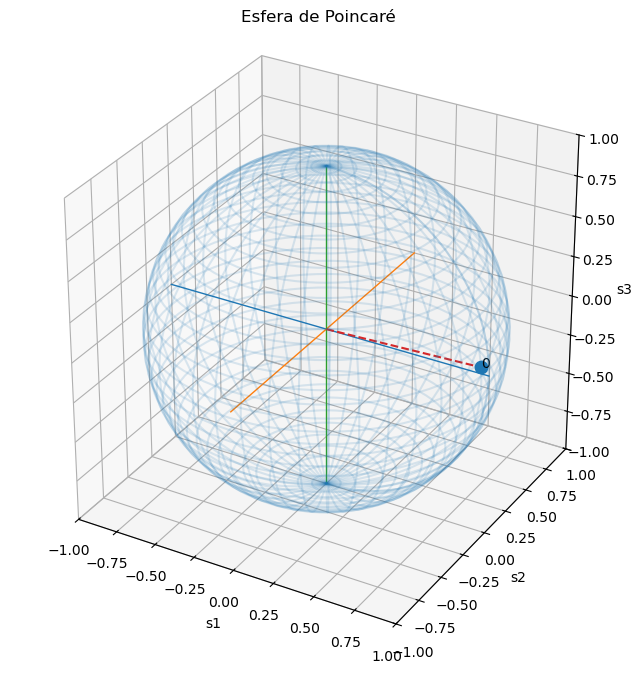

In [7]:
plot_poincare_sphere([res])